# CIFAR-10 Image Classification with CNNs (TensorFlow / Keras)

**Author's mentor note:** This notebook builds a complete image classification pipeline
from scratch on the CIFAR-10 dataset — 60,000 32x32 color images across 10 classes
(airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).

**Pipeline overview:**
1. Environment setup
2. Dataset loading
3. Data visualization
4. Preprocessing (normalization, train/val/test split)
5. CNN architecture (Conv2D, BatchNorm, MaxPooling, Dropout, Dense)
6. Compilation
7. Training (15–20 epochs)
8. Accuracy/loss curves
9. Evaluation on the test set
10. Confusion matrix
11. Correctly vs. incorrectly classified images
12. Classification report
13. Saving the trained model

Runs unmodified in Jupyter Notebook or Google Colab (GPU runtime recommended for speed,
but not required).

## Step 0 — Environment Setup

Before touching data, we import every library we'll need and fix random seeds so the
notebook produces (nearly) reproducible results run to run. We also check whether a GPU
is available — CIFAR-10 training is much faster with one, but the code works fine on CPU
too (just slower).

In [2]:
import sys
print(sys.executable)

import tensorflow as tf
print(tf.__version__)


d:\Enginow\cnn image detection\venv\Scripts\python.exe
2.21.0


In [3]:
# ===== Core imports =====
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ===== Reproducibility =====
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ===== Sanity checks =====
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {[g.name for g in gpus]} — training will use the GPU.")
else:
    print("No GPU detected — training will run on CPU (this will be slower).")

# Class names for CIFAR-10, in label-index order (0-9)
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

TensorFlow version: 2.21.0
No GPU detected — training will run on CPU (this will be slower).


## Step 1 — Dataset Loading

CIFAR-10 ships directly with Keras (`keras.datasets.cifar10`), so no manual download is
needed — it fetches and caches the data automatically (~170 MB, one-time download).

It arrives pre-split into 50,000 training images and 10,000 test images, each
`32x32x3` (RGB), with integer labels `0-9`. We wrap the load in a `try/except` so a
network hiccup produces a clear error message instead of a cryptic traceback.

In [4]:
# ===== Load CIFAR-10 =====
try:
    (x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
except Exception as e:
    raise RuntimeError(
        "Failed to download/load CIFAR-10. Check your internet connection "
        f"(Colab/Jupyter needs to reach Keras' dataset servers). Original error: {e}"
    )

# Labels come back as shape (N, 1); flatten to (N,) for convenience
y_train_full = y_train_full.flatten()
y_test = y_test.flatten()

print("Full training set:", x_train_full.shape, y_train_full.shape)
print("Test set:          ", x_test.shape, y_test.shape)
print("Pixel value range: ", x_train_full.min(), "to", x_train_full.max())

Full training set: (50000, 32, 32, 3) (50000,)
Test set:           (10000, 32, 32, 3) (10000,)
Pixel value range:  0 to 255


## Step 2 — Data Visualization

Always *look* at your data before modeling. We check two things:
- **Sample images per class**, to confirm labels look sensible and images aren't corrupted.
- **Class distribution**, to confirm CIFAR-10 is balanced (it is — 6,000 images/class),
  which matters because an imbalanced dataset would need different handling (e.g. class
  weights).

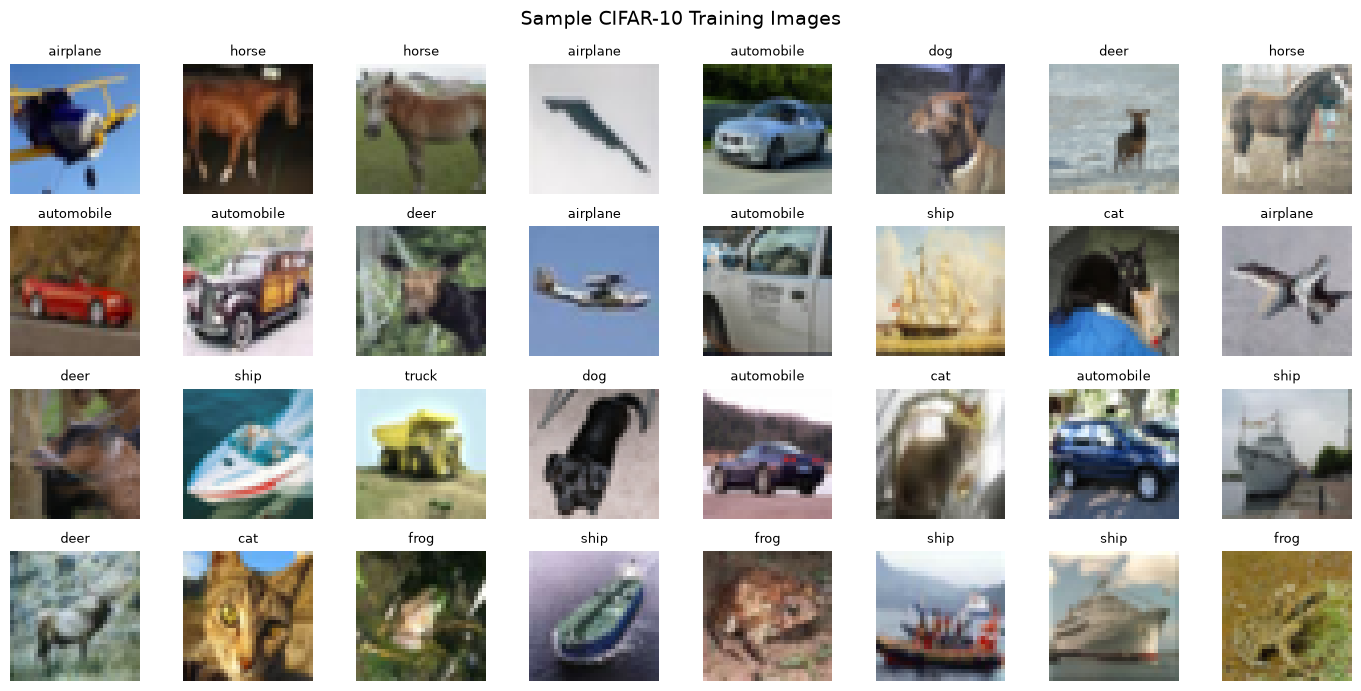

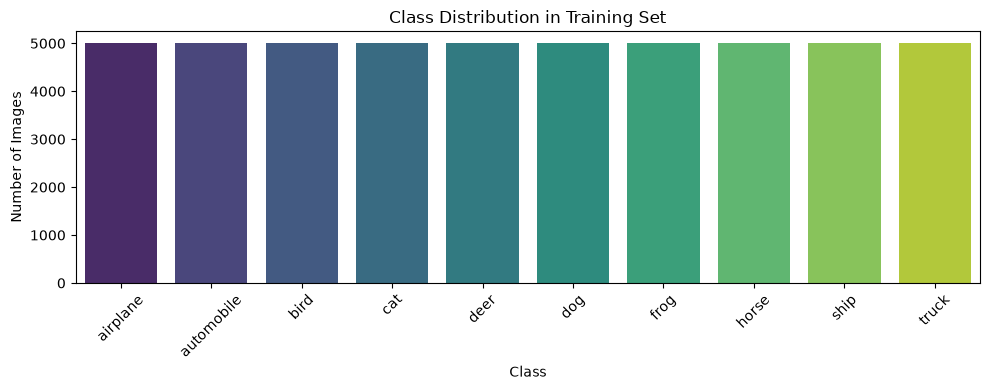

Images per class: {'airplane': 5000, 'automobile': 5000, 'bird': 5000, 'cat': 5000, 'deer': 5000, 'dog': 5000, 'frog': 5000, 'horse': 5000, 'ship': 5000, 'truck': 5000}


In [5]:
# ===== Visualize sample images =====
fig, axes = plt.subplots(4, 8, figsize=(14, 7))
axes = axes.flatten()
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_train_full), size=32, replace=False)

for ax, idx in zip(axes, sample_idx):
    ax.imshow(x_train_full[idx])
    ax.set_title(CLASS_NAMES[y_train_full[idx]], fontsize=9)
    ax.axis('off')

plt.suptitle("Sample CIFAR-10 Training Images", fontsize=14)
plt.tight_layout()
plt.show()

# ===== Class distribution =====
unique, counts = np.unique(y_train_full, return_counts=True)
plt.figure(figsize=(10, 4))
sns.barplot(x=[CLASS_NAMES[u] for u in unique], y=counts, hue=[CLASS_NAMES[u] for u in unique],
            palette='viridis', legend=False)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Images per class:", dict(zip([CLASS_NAMES[u] for u in unique], counts)))

## Step 3 — Image Preprocessing

Two preprocessing steps here:

**1. Normalization.** Raw pixel values are integers in `[0, 255]`. Neural networks train
faster and more stably on small, zero-centered-ish ranges, so we rescale to `[0, 1]` by
dividing by 255.0 (float32 division). We deliberately do *not* subtract a channel mean here
to keep preprocessing simple and identical at train/inference time — the CNN's
BatchNormalization layers handle further internal rescaling.

**2. Train/Validation/Test split.** CIFAR-10 gives us a 50k/10k train/test split
out of the box. The test set must stay completely untouched until final evaluation
(Step 8) — otherwise we'd be tuning on data we're supposed to be measuring against. So we
carve a **validation set** out of the 50k training images (90/10 split, stratified by
class so each split keeps the same class balance) to monitor training and tune the model
without touching the test set.

In [6]:
# ===== Normalization: scale pixel values from [0,255] to [0,1] =====
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# ===== Train / Validation split (stratified so class balance is preserved) =====
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.10,          # 10% of training data held out for validation
    random_state=SEED,
    stratify=y_train_full
)

print("Train shape:     ", x_train.shape, y_train.shape)
print("Validation shape:", x_val.shape, y_val.shape)
print("Test shape:      ", x_test.shape, y_test.shape)
print("\nPixel range after normalization: "
      f"[{x_train.min():.2f}, {x_train.max():.2f}]")

Train shape:      (45000, 32, 32, 3) (45000,)
Validation shape: (5000, 32, 32, 3) (5000,)
Test shape:       (10000, 32, 32, 3) (10000,)

Pixel range after normalization: [0.00, 1.00]


## Step 4 — CNN Architecture

Design rationale (this is the part interviewers love to probe, see the viva section at
the end):

- **3 convolutional blocks**, each with two `Conv2D` layers (a "double conv" pattern —
  more effective receptive field growth than a single wide conv) followed by
  `BatchNormalization`, `MaxPooling2D`, and `Dropout`. Filter counts double each block
  (32 → 64 → 128) as spatial resolution shrinks (32×32 → 16×16 → 8×8 → 4×4), which is the
  standard CNN design trade-off: fewer pixels, more feature channels.
- **BatchNormalization** after every conv layer stabilizes and speeds up training by
  normalizing layer activations, and lets us use a higher learning rate safely.
- **Dropout**, with an increasing rate deeper into the network (0.25 → 0.3 → 0.4 → 0.5),
  randomly deactivates neurons during training to fight overfitting — CIFAR-10 is small
  enough that a CNN this size can otherwise memorize the training set.
- **`padding='same'`** keeps spatial dimensions unchanged after each conv, so only the
  explicit `MaxPooling2D` layers shrink the feature maps — this makes the architecture's
  downsampling schedule easy to read at a glance.
- **Dense head**: `Flatten` → `Dense(128, relu)` → `BatchNorm` → `Dropout(0.5)` →
  `Dense(10, softmax)` for the final 10-class probability distribution.

In [7]:
def build_model(input_shape=(32, 32, 3), num_classes=10):
    """Builds and returns a compiled-ready CNN for CIFAR-10 classification."""
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # ----- Conv Block 1: 32 filters -----
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),      # 32x32 -> 16x16
        layers.Dropout(0.25),

        # ----- Conv Block 2: 64 filters -----
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),      # 16x16 -> 8x8
        layers.Dropout(0.3),

        # ----- Conv Block 3: 128 filters -----
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),      # 8x8 -> 4x4
        layers.Dropout(0.4),

        # ----- Dense classification head -----
        layers.Flatten(),                  # 4x4x128 -> 2048
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name="cifar10_cnn")

    return model

model = build_model()
model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

### Reading the `model.summary()` output

Running the cell above prints a layer-by-layer table. Here's what to expect and why
(computed directly from the architecture, so these numbers should match your run exactly
on TensorFlow 2.x):

| Block | Layer | Output Shape | Params |
|---|---|---|---|
| 1 | Conv2D(32) | (32,32,32) | 896 |
| 1 | BatchNorm | (32,32,32) | 128 |
| 1 | Conv2D(32) | (32,32,32) | 9,248 |
| 1 | BatchNorm | (32,32,32) | 128 |
| 1 | MaxPool | (16,16,32) | 0 |
| 2 | Conv2D(64) | (16,16,64) | 18,496 |
| 2 | BatchNorm | (16,16,64) | 256 |
| 2 | Conv2D(64) | (16,16,64) | 36,928 |
| 2 | BatchNorm | (16,16,64) | 256 |
| 2 | MaxPool | (8,8,64) | 0 |
| 3 | Conv2D(128) | (8,8,128) | 73,856 |
| 3 | BatchNorm | (8,8,128) | 512 |
| 3 | Conv2D(128) | (8,8,128) | 147,584 |
| 3 | BatchNorm | (8,8,128) | 512 |
| 3 | MaxPool | (4,4,128) | 0 |
| — | Flatten | (2048,) | 0 |
| — | Dense(128) | (128,) | 262,272 |
| — | BatchNorm | (128,) | 512 |
| — | Dense(10) | (10,) | 1,290 |

**Totals: 552,874 parameters — 551,722 trainable, 1,152 non-trainable.**

The non-trainable params come entirely from BatchNormalization's *moving mean* and
*moving variance* statistics (2 per channel per BN layer) — these are updated via
running averages during training, not by gradient descent, which is why Keras reports
them separately from the "trainable" (gradient-updated) weights like conv kernels,
biases, and BN's gamma/beta.

Notice how the **Conv2D layers dominate the early param counts** relative to spatial
size, while the **first Dense layer alone contributes ~262k params** (nearly half the
model) — this is the classic CNN pattern: convolutions are parameter-efficient per
pixel, but flattening into a dense layer is expensive. It's also why deeper CNNs often
use Global Average Pooling instead of Flatten to cut params — worth experimenting with
as a follow-up (see "Future Improvements" in the report template).

## Step 5 — Model Compilation

- **Optimizer: Adam** — adaptive learning rate, a strong default for CNNs that converges
  faster than plain SGD with little tuning.
- **Loss: `sparse_categorical_crossentropy`** — the right choice because our labels are
  plain integers (0-9) rather than one-hot vectors; it computes the same math as
  categorical crossentropy without the extra one-hot encoding step.
- **Metric: `accuracy`** — the fraction of correctly classified images, tracked on both
  train and validation sets each epoch.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


## Step 6 — Model Training

Training uses three industry-standard additions on top of the plain `model.fit` call:

1. **Light data augmentation** (`ImageDataGenerator`): random horizontal flips and small
   shifts/rotations on the *training* set only. CIFAR-10 is small (45k images after our
   split), so augmentation acts as a cheap regularizer against overfitting by showing the
   model slightly varied versions of each image every epoch.
2. **`EarlyStopping`**: stops training if validation loss stops improving for 5 epochs and
   restores the best-performing weights — protects us from overfitting in later epochs.
3. **`ReduceLROnPlateau`**: halves the learning rate if validation loss plateaus for 3
   epochs, helping the model fine-tune once progress slows.

We train for up to 20 epochs (per the requirement), with `batch_size=64`.

In [9]:
# ===== Data augmentation (training data only — never augment val/test) =====
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

# ===== Callbacks =====
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
]

EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 271s 379ms/step - accuracy: 0.4015 - loss: 1.7400 - val_accuracy: 0.2922 - val_loss: 2.8846 - learning_rate: 0.0010
Epoch 2/20
  1/703 ━━━━━━━━━━━━━━━━━━━━ 2:42 231ms/step - accuracy: 0.5625 - loss: 1.2647

d:\Enginow\cnn image detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


703/703 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5625 - loss: 1.2647 - val_accuracy: 0.2810 - val_loss: 2.9857 - learning_rate: 0.0010
Epoch 3/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 170s 241ms/step - accuracy: 0.5648 - loss: 1.2244 - val_accuracy: 0.5518 - val_loss: 1.3542 - learning_rate: 0.0010
Epoch 4/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6875 - loss: 0.9492 - val_accuracy: 0.5730 - val_loss: 1.2666 - learning_rate: 0.0010
Epoch 5/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 207s 294ms/step - accuracy: 0.6282 - loss: 1.0575 - val_accuracy: 0.6744 - val_loss: 0.9235 - learning_rate: 0.0010
Epoch 6/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7031 - loss: 0.9453 - val_accuracy: 0.6774 - val_loss: 0.9091 - learning_rate: 0.0010
Epoch 7/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 190s 270ms/step - accuracy: 0.6683 - loss: 0.9472 - val_accuracy: 0.6698 - val_loss: 0.9787 - learning_rate: 0.0010
Epoch 8/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6562 - loss: 1.0682 -

## Step 7 — Accuracy and Loss Plots

Plotting training vs. validation curves side by side is the fastest way to diagnose
what's happening:
- Both curves rising/falling together → healthy training.
- Training accuracy much higher than validation accuracy (a growing gap) → overfitting.
- Both curves stuck / not improving → underfitting, or learning rate issues.

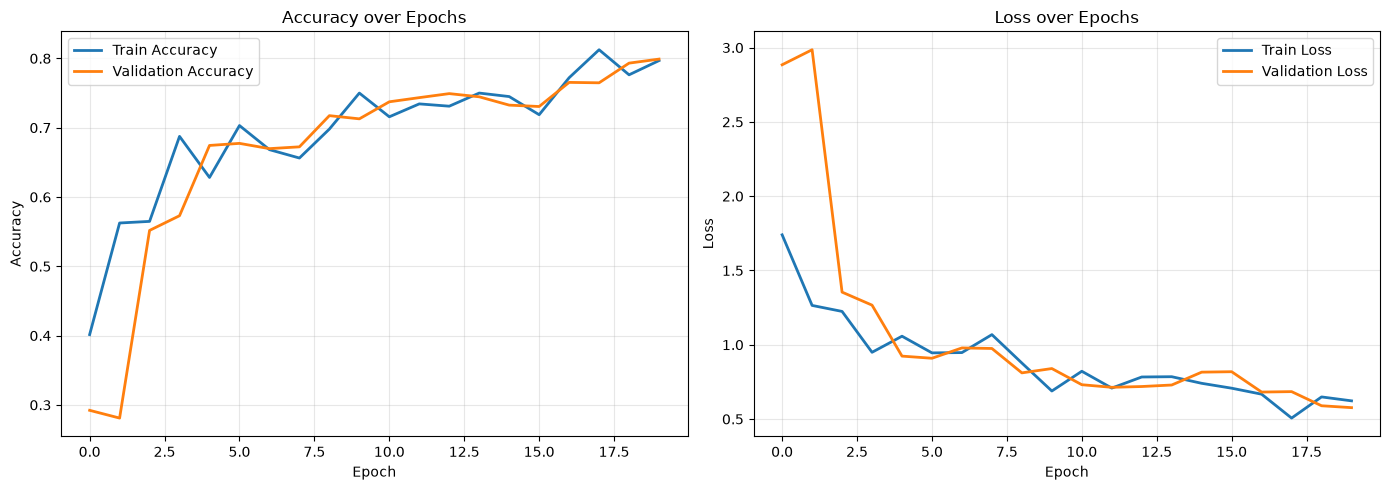

Best validation accuracy: 0.7990
Best validation loss:     0.5766


In [15]:
history_df = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_df['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_df['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history_df['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_df['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("assets/training_curves.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

print(f"Best validation accuracy: {max(history_df['val_accuracy']):.4f}")
print(f"Best validation loss:     {min(history_df['val_loss']):.4f}")

## Step 8 — Model Evaluation

Now, and only now, we touch the held-out **test set** — data the model has never seen in
any form (not even for early stopping decisions) — to get an unbiased estimate of
real-world performance.

In [16]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Generate predictions for downstream analysis (confusion matrix, reports, etc.)
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

Test Loss:     0.6125
Test Accuracy: 0.7909 (79.09%)


## Step 9 — Confusion Matrix

The confusion matrix shows, for every true class (rows), how predictions were
distributed across predicted classes (columns). The diagonal = correct predictions;
anything off-diagonal is a specific type of mistake (e.g. "cat predicted as dog") —
far more informative than a single accuracy number, especially for spotting which
classes get confused with each other.

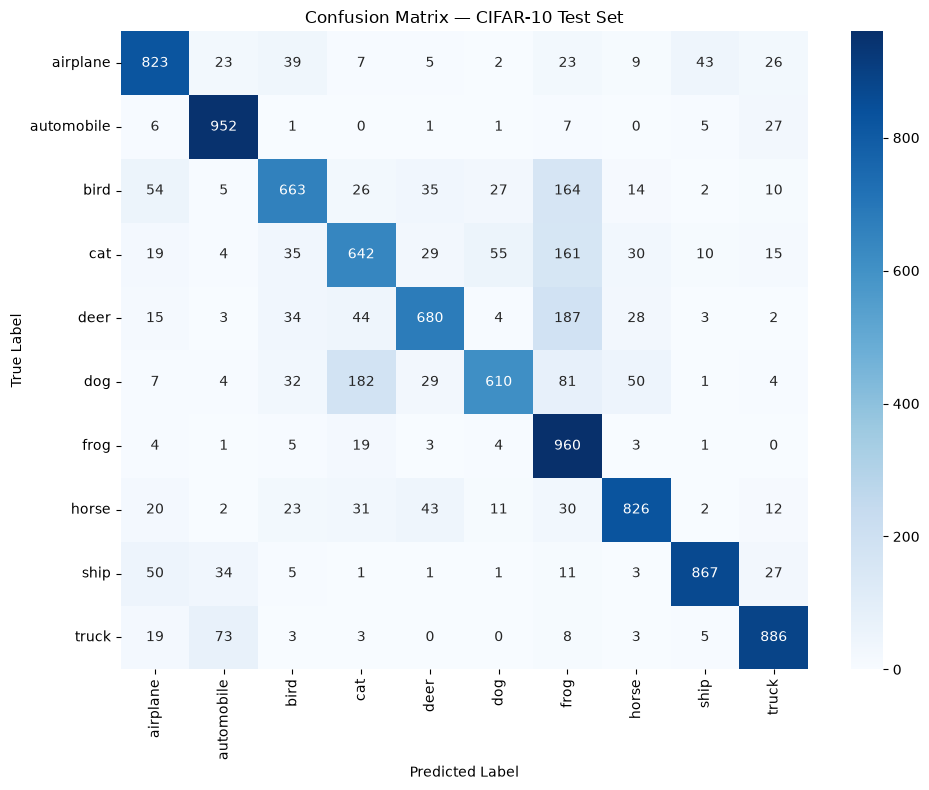

<Figure size 640x480 with 0 Axes>

In [17]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — CIFAR-10 Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
plt.savefig("assets/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 10 — Correctly vs. Incorrectly Classified Images

Numbers only tell part of the story — looking at *which* images the model gets wrong
often reveals patterns (e.g. confusing visually similar classes like cat/dog, or
struggling with occluded/blurry images).

Correct predictions:   7909 / 10000
Incorrect predictions: 2091 / 10000


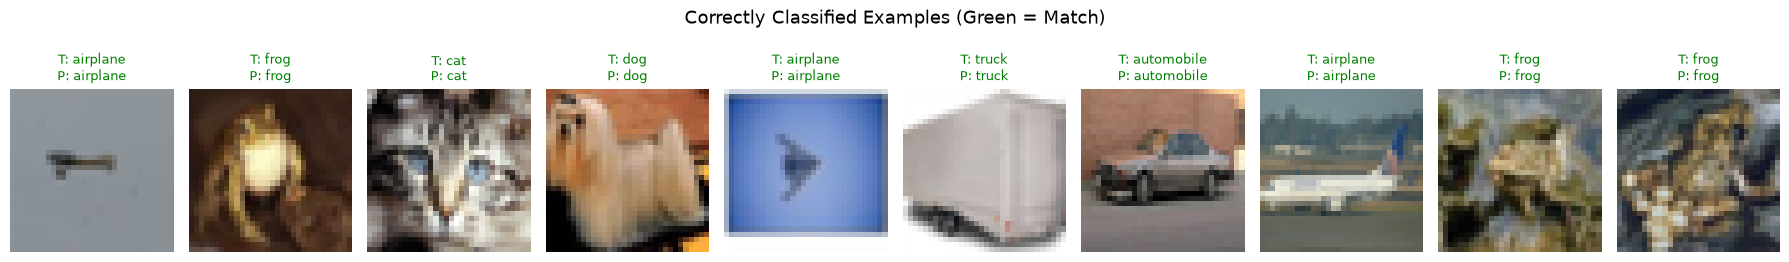

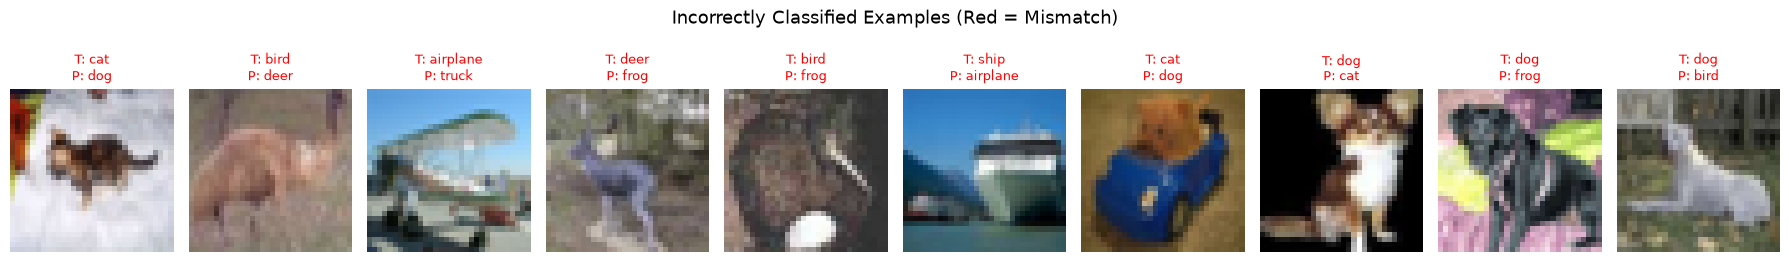

In [18]:
correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

print(f"Correct predictions:   {len(correct_idx)} / {len(y_test)}")
print(f"Incorrect predictions: {len(incorrect_idx)} / {len(y_test)}")

def plot_examples(indices, title, n=10):
    fig, axes = plt.subplots(1, n, figsize=(18, 3))
    chosen = np.random.default_rng(SEED).choice(indices, size=min(n, len(indices)), replace=False)
    for ax, idx in zip(axes, chosen):
        ax.imshow(x_test[idx])
        true_label = CLASS_NAMES[y_test[idx]]
        pred_label = CLASS_NAMES[y_pred[idx]]
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=9, color=color)
        ax.axis('off')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig("assets/sample_predictions.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()

plot_examples(correct_idx, "Correctly Classified Examples (Green = Match)")
plot_examples(incorrect_idx, "Incorrectly Classified Examples (Red = Mismatch)")

## Step 11 — Classification Report

`classification_report` breaks accuracy down **per class** into precision, recall, and
F1-score — essential because overall accuracy can hide poor performance on individual
classes (e.g. a model could be great at "ship" but bad at "cat" while still posting a
decent aggregate number).

In [19]:
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4)
print(report)

              precision    recall  f1-score   support

    airplane     0.8092    0.8230    0.8161      1000
  automobile     0.8647    0.9520    0.9062      1000
        bird     0.7893    0.6630    0.7207      1000
         cat     0.6723    0.6420    0.6568      1000
        deer     0.8232    0.6800    0.7448      1000
         dog     0.8531    0.6100    0.7114      1000
        frog     0.5882    0.9600    0.7295      1000
       horse     0.8551    0.8260    0.8403      1000
        ship     0.9233    0.8670    0.8943      1000
       truck     0.8781    0.8860    0.8820      1000

    accuracy                         0.7909     10000
   macro avg     0.8057    0.7909    0.7902     10000
weighted avg     0.8057    0.7909    0.7902     10000



## Step 12 — Saving the Trained Model

We save in the modern **`.keras`** format (the current recommended format in TensorFlow
2.x — a single self-contained file including architecture, weights, and optimizer
state), and also export a legacy **`.h5`** copy for compatibility with older tooling or
environments that expect it. Both calls are wrapped in error handling so a disk/permission
issue doesn't silently fail.

In [20]:
MODEL_DIR = "saved_model"
os.makedirs(MODEL_DIR, exist_ok=True)

try:
    keras_path = os.path.join(MODEL_DIR, "cifar10_cnn_model.keras")
    model.save(keras_path)
    print(f"Model saved (Keras v3 format): {keras_path}")
except Exception as e:
    print(f"Failed to save .keras model: {e}")

try:
    h5_path = os.path.join(MODEL_DIR, "cifar10_cnn_model.h5")
    model.save(h5_path)
    print(f"Model saved (HDF5 legacy format): {h5_path}")
except Exception as e:
    print(f"Failed to save .h5 model: {e}")

# ===== Reloading sanity check =====
try:
    reloaded = keras.models.load_model(keras_path)
    reload_loss, reload_acc = reloaded.evaluate(x_test, y_test, verbose=0)
    print(f"\nReloaded model test accuracy: {reload_acc:.4f} (should match Step 8 result)")
except Exception as e:
    print(f"Model reload check failed: {e}")

Model saved (Keras v3 format): saved_model\cifar10_cnn_model.keras
Model saved (HDF5 legacy format): saved_model\cifar10_cnn_model.h5

Reloaded model test accuracy: 0.7909 (should match Step 8 result)


## Wrap-Up

You've now got a full CNN image classification pipeline: loaded and visualized CIFAR-10,
normalized and split the data, built and explained a 3-block CNN with BatchNorm/Dropout,
trained it with augmentation and callbacks, evaluated it with plots/confusion
matrix/classification report, inspected specific predictions, and saved the model in two
formats.

See the accompanying **`report_template.md`** to write up your results, and
**`viva_questions.md`** to prep for interview/viva questions on the concepts used here.